# Phase 2 — Pipeline régime-aware sur FD002

Objectif : vérifier visuellement que la normalisation par régime fonctionne comme attendu sur
FD002, avant de passer à l'ablation (test H3, notebook suivant) qui la comparera à une
normalisation globale (comme sur FD001).

**Sélection de capteurs par régime** : `select_features` (écart-type global) garderait à tort
des capteurs constants DANS chaque régime mais qui semblent varier globalement à cause du seul
changement de régime (ex. `sensor_1`, constant sur FD001, mais dont l'écart-type global sur
FD002 dépasse le seuil). Diviser par un écart-type quasi nul dans `normalize_by_regime`
produit des NaN — rencontré concrètement en développant `11_fd002_ablation_regime.ipynb`. On
utilise donc `select_features_by_regime`, qui exige une variance suffisante dans TOUS les
régimes, pas seulement globalement.

Critère « fait » (plan d'exécution, Phase 2) : régimes identifiés, normalisation par groupe.

In [1]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd

from src.preprocessing import (
    assign_regimes,
    compute_norm_stats_by_regime,
    fit_regime_clusters,
    normalize_by_regime,
    select_features_by_regime,
    split_by_unit,
)

SEED = 42
DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

raw = pd.read_csv(f"{DATA_DIR}/train_FD002.txt", sep=r"\s+", header=None)
raw = raw.iloc[:, : len(COL_NAMES)]
raw.columns = COL_NAMES

train_raw, val_raw = split_by_unit(raw, val_fraction=0.2, seed=SEED)
print("Moteurs train :", train_raw["unit_number"].nunique(), "— Moteurs val :", val_raw["unit_number"].nunique())

Moteurs train : 208 — Moteurs val : 52


In [2]:
regime_model = fit_regime_clusters(train_raw, SETTING_NAMES, n_regimes=6, seed=SEED)
train_regimes = assign_regimes(train_raw, SETTING_NAMES, regime_model)
val_regimes = assign_regimes(val_raw, SETTING_NAMES, regime_model)  # même modèle que le train, jamais réajusté

selected_sensors = select_features_by_regime(train_raw, SENSOR_NAMES, train_regimes, std_threshold=1e-2)
print(f"Capteurs gardés ({len(selected_sensors)}) :", selected_sensors)

stats_by_regime = compute_norm_stats_by_regime(train_raw, selected_sensors, train_regimes)
train_norm = normalize_by_regime(train_raw, selected_sensors, train_regimes, stats_by_regime)
val_norm = normalize_by_regime(val_raw, selected_sensors, val_regimes, stats_by_regime)

Capteurs gardés (14) : ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7', 'sensor_8', 'sensor_9', 'sensor_11', 'sensor_12', 'sensor_13', 'sensor_14', 'sensor_15', 'sensor_17', 'sensor_20', 'sensor_21']


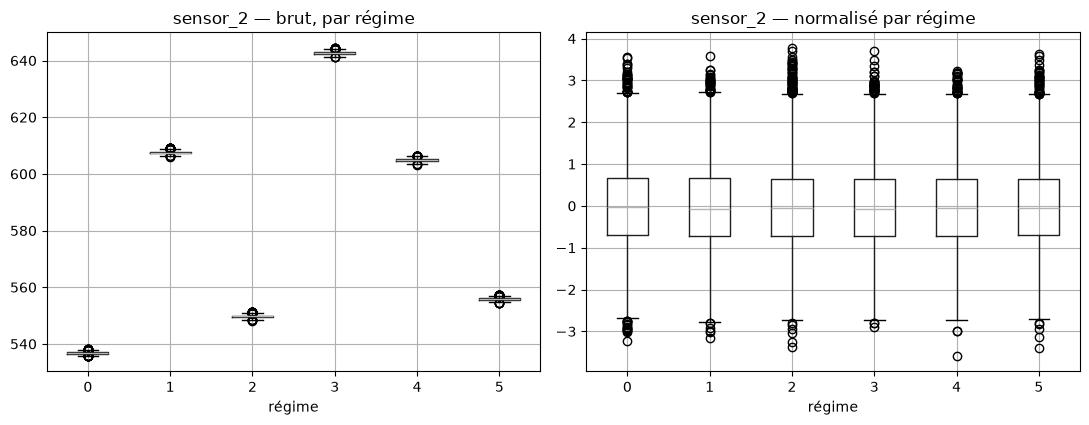

In [3]:
example_sensor = selected_sensors[0]
train_raw_plot = train_raw.assign(regime=train_regimes)
train_norm_plot = train_norm.assign(regime=train_regimes)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
train_raw_plot.boxplot(column=example_sensor, by="regime", ax=axes[0])
axes[0].set_title(f"{example_sensor} — brut, par régime")
axes[0].set_xlabel("régime")

train_norm_plot.boxplot(column=example_sensor, by="regime", ax=axes[1])
axes[1].set_title(f"{example_sensor} — normalisé par régime")
axes[1].set_xlabel("régime")

fig.suptitle("")
fig.tight_layout()

**Ce que montrent ces figures** : à gauche, le capteur illustré ci-dessus, brut, par régime —
si les 6 boîtes sont centrées sur des valeurs très différentes, c'est la signature d'un
capteur sensible au point de fonctionnement (pas seulement à l'usure du moteur). À droite, le
même capteur après normalisation par régime : les 6 boîtes doivent maintenant être centrées
sur 0 avec une échelle comparable, quel que soit le régime d'origine. C'est exactement l'effet
recherché : une normalisation globale (comme sur FD001) aurait mélangé ces 6 échelles
différentes en une seule, rendant impossible de distinguer un vrai signal de dégradation d'un
simple changement de régime opérationnel.